In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
import seaborn as sns

Total Cases Analyzed: 13087
High-Risk Anomalies Detected: 131

TOP 5 HIGH-RISK CASES REQUIRING IMMEDIATE INVESTIGATION:
         duration_sec  event_count  unique_users  anomaly_score  \
case_id                                                           
173694   1.185234e+07           59            10             -1   
173784   3.865480e+06          108            14             -1   
173928   4.978652e+06          115            20             -1   
173955   4.981812e+06           89            17             -1   
174060   6.122966e+06          127            15             -1   

                  risk_level  
case_id                       
173694   High Risk (Anomaly)  
173784   High Risk (Anomaly)  
173928   High Risk (Anomaly)  
173955   High Risk (Anomaly)  
174060   High Risk (Anomaly)  


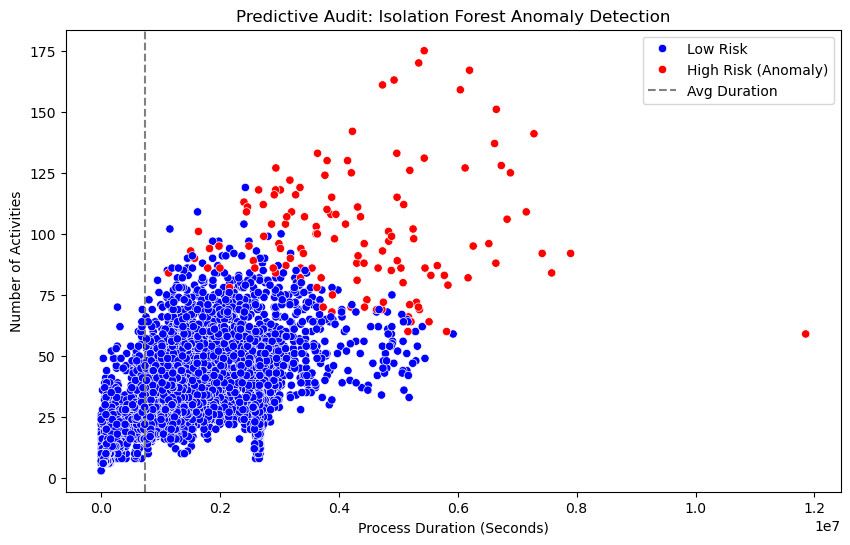

In [5]:
def run_predictive_monitor(filepath):

    # 1. DATA INGESTION & FEATURE ENGINEERING
    df = pd.read_csv(filepath)

    df['timestamp'] = pd.to_datetime(
        df['timestamp'],
        format='mixed',
        utc=True,
        errors='coerce'
    )

    df = df.dropna(subset=['timestamp'])

    df = df.sort_values(by=['case_id', 'timestamp'])

    # Feature 1: Case Duration (How long does the whole process take?)
    case_durations = df.groupby('case_id')['timestamp'].agg(lambda x: (x.max() - x.min()).total_seconds())
    
    # Feature 2: Event Count (How many steps were taken? Too few might mean bypassed controls)
    event_counts = df.groupby('case_id')['activity'].count()
    
    # Feature 3: Unique Users (How many people were involved? Too few might mean SoD risk)
    user_counts = df.groupby('case_id')['user_id'].nunique()

    # Combine into a Feature Matrix for the ML Model
    features = pd.concat([case_durations, event_counts, user_counts], axis=1)
    features.columns = ['duration_sec', 'event_count', 'unique_users']

    # 2. MODEL INITIALIZATION (Isolation Forest)
    # contamination=0.01 means we expect 1% of the banking data to be anomalous/risky
    model = IsolationForest(contamination=0.01, random_state=42)
    
    # 3. TRAINING & PREDICTION
    # The model "learns" the normal heartbeat of the bank's operations
    features['anomaly_score'] = model.fit_predict(features[['duration_sec', 'event_count', 'unique_users']])
    
    # Mapping: Isolation Forest outputs -1 for anomalies and 1 for normal data
    features['risk_level'] = features['anomaly_score'].map({1: 'Low Risk', -1: 'High Risk (Anomaly)'})

    # 4. RESULTS & AUDIT INSIGHTS
    anomalies = features[features['anomaly_score'] == -1]
    print(f"Total Cases Analyzed: {len(features)}")
    print(f"High-Risk Anomalies Detected: {len(anomalies)}")
    
    # Outputting the Top 5 most anomalous cases for immediate Auditor investigation
    print("\nTOP 5 HIGH-RISK CASES REQUIRING IMMEDIATE INVESTIGATION:")
    print(anomalies.head())

    # 5. VISUALIZATION (The Predictive Dashboard)
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=features, x='duration_sec', y='event_count', hue='risk_level',
                    palette={'Low Risk': 'blue', 'High Risk (Anomaly)': 'red'})
    plt.title('Predictive Audit: Isolation Forest Anomaly Detection')
    plt.xlabel('Process Duration (Seconds)')
    plt.ylabel('Number of Activities')
    plt.axvline(features['duration_sec'].mean(), color='grey', linestyle='--', label='Avg Duration')
    plt.legend()
    plt.show()

    return features

 #--- EXECUTION ---
result_ml = run_predictive_monitor('event_log.csv')
